In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load dataset
df = pd.read_csv('USA_cars_datasets.csv', index_col=0)

# Basic cleaning
df.columns = df.columns.str.strip()
df['brand']     = df['brand'].str.strip().str.title()
df['color']     = df['color'].str.strip().str.title()
df['condition'] = df['condition'].str.strip()
df['state']     = df['state'].str.strip().str.title()

# Remove extreme outliers in price (keep below 99th percentile)
price_cap = df['price'].quantile(0.99)
df = df[df['price'] <= price_cap]

# Remove zero-price entries
df = df[df['price'] > 0]

print('Shape:', df.shape)
print('\nMissing values:\n', df.isnull().sum())
print('\nUnique conditions:', df['condition'].unique())
df.head()

Shape: (2431, 12)

Missing values:
 price           0
brand           0
model           0
year            0
title_status    0
mileage         0
color           0
vin             0
lot             0
state           0
country         0
condition       0
dtype: int64

Unique conditions: ['10 days left' '6 days left' '2 days left' '22 hours left'
 '20 hours left' '19 hours left' '3 days left' '21 hours left'
 '17 hours left' '2 hours left' '3 hours left' '34 minutes'
 '16 hours left' '18 hours left' '1 days left' '32 minutes'
 '14 hours left' '5 hours left' '4 days left' '9 days left'
 '23 hours left' '7 days left' '8 days left' '5 days left' '9 minutes'
 '1 minutes' '7 hours left' '16 minutes' '6 hours left' '1 hours left'
 'Listing Expired' '13 days left' '24 hours left' '15 hours left'
 '53 minutes' '27 minutes' '12 days left' '15 days left' '30 minutes'
 '29 minutes' '28 minutes' '48 minutes' '11 days left' '4 hours left'
 '47 minutes' '12 hours left' '36 minutes']


,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,6300,Toyota,cruiser,2008,clean vehicle,274117.0,Black,jtezu11f88k007763,159348797,New Jersey,usa,10 days left
1,2899,Ford,se,2011,clean vehicle,190552.0,Silver,2fmdk3gc4bbb02217,166951262,Tennessee,usa,6 days left
2,5350,Dodge,mpv,2018,clean vehicle,39590.0,Silver,3c4pdcgg5jt346413,167655728,Georgia,usa,2 days left
3,25000,Ford,door,2014,clean vehicle,64146.0,Blue,1ftfw1et4efc23745,167753855,Virginia,usa,22 hours left
4,27700,Chevrolet,1500,2018,clean vehicle,6654.0,Red,3gcpcrec2jg473991,167763266,Florida,usa,22 hours left


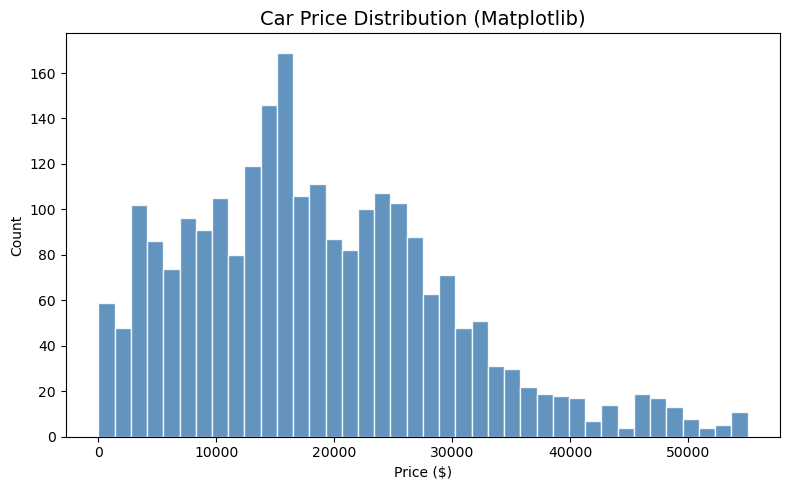

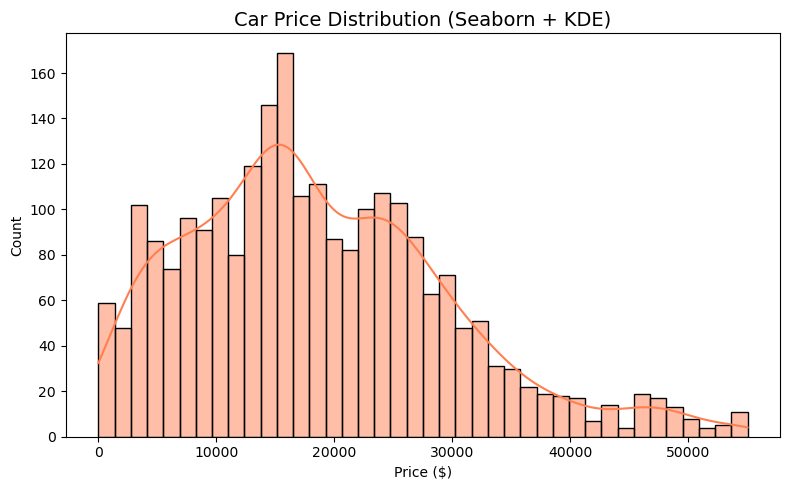

Insight: Most cars are priced below $15,000. The distribution is right-skewed.


In [2]:
# --- 2a: Matplotlib histogram ---
plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Car Price Distribution (Matplotlib)', fontsize=14)
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# --- 2b: Seaborn histogram with KDE ---
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=40, kde=True, color='coral')
plt.title('Car Price Distribution (Seaborn + KDE)', fontsize=14)
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# --- 2c: Plotly interactive histogram ---
fig = px.histogram(df, x='price', nbins=40,
                   title='Car Price Distribution (Plotly — Interactive)',
                   labels={'price': 'Price ($)'},
                   color_discrete_sequence=['#636EFA'])
fig.update_layout(bargap=0.05)
fig.show()

print('Insight: Most cars are priced below $15,000. The distribution is right-skewed.')

C:\Users\hp\AppData\Local\Temp\ipykernel_24848\3689751223.py:11: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



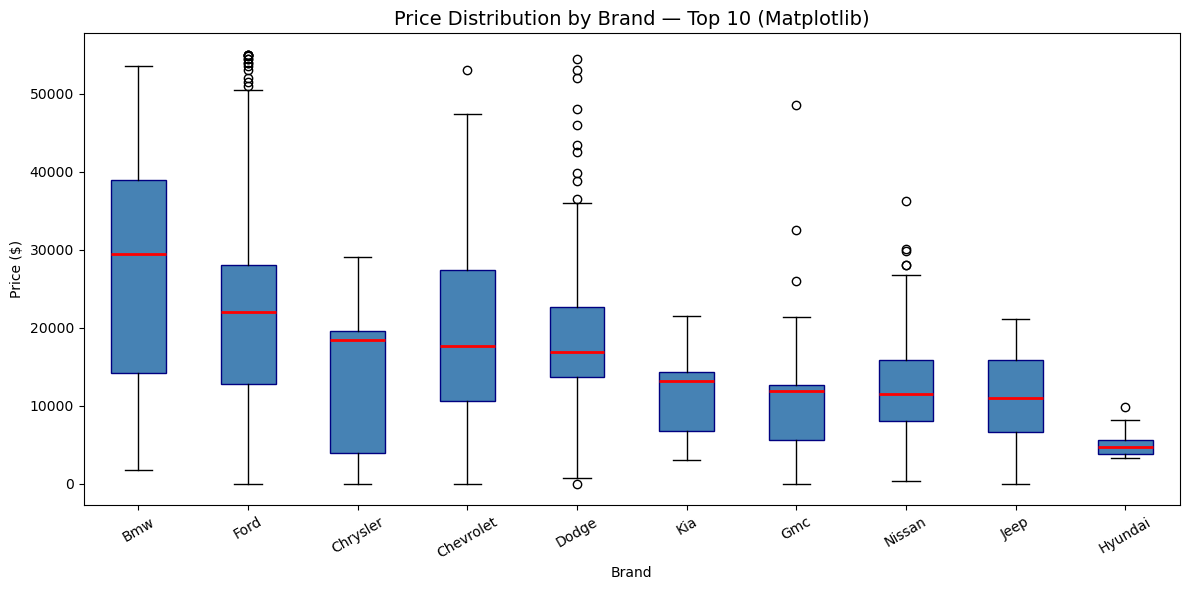

C:\Users\hp\AppData\Local\Temp\ipykernel_24848\3689751223.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




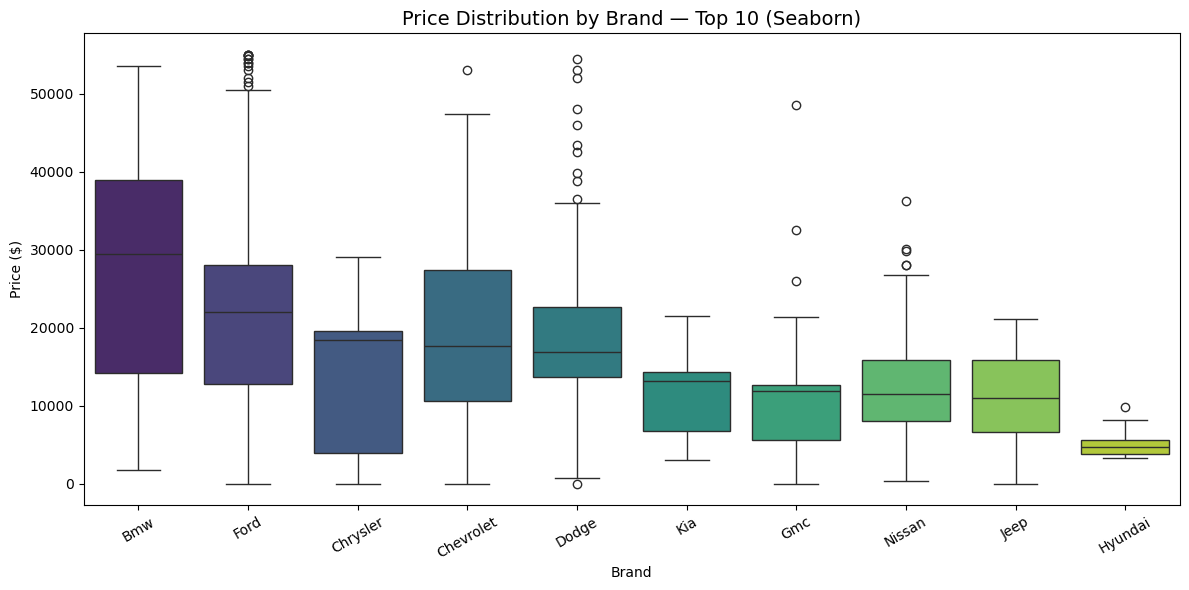

Insight: Dodge and Chevrolet show higher price variability; Ford has the most listings.


In [3]:
# Select top 10 brands by listing count
top10_brands = df['brand'].value_counts().head(10).index
df_top10 = df[df['brand'].isin(top10_brands)]

# Sort brands by median price for readability
brand_order = df_top10.groupby('brand')['price'].median().sort_values(ascending=False).index

# --- 3a: Matplotlib box plot ---
plt.figure(figsize=(12, 6))
data_by_brand = [df_top10[df_top10['brand'] == b]['price'].values for b in brand_order]
plt.boxplot(data_by_brand, labels=brand_order, patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='navy'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Price Distribution by Brand — Top 10 (Matplotlib)', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Price ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# --- 3b: Seaborn box plot ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top10, x='brand', y='price',
            order=brand_order, palette='viridis')
plt.title('Price Distribution by Brand — Top 10 (Seaborn)', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Price ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print('Insight: Dodge and Chevrolet show higher price variability; Ford has the most listings.')

C:\Users\hp\AppData\Local\Temp\ipykernel_24848\2827281961.py:27: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



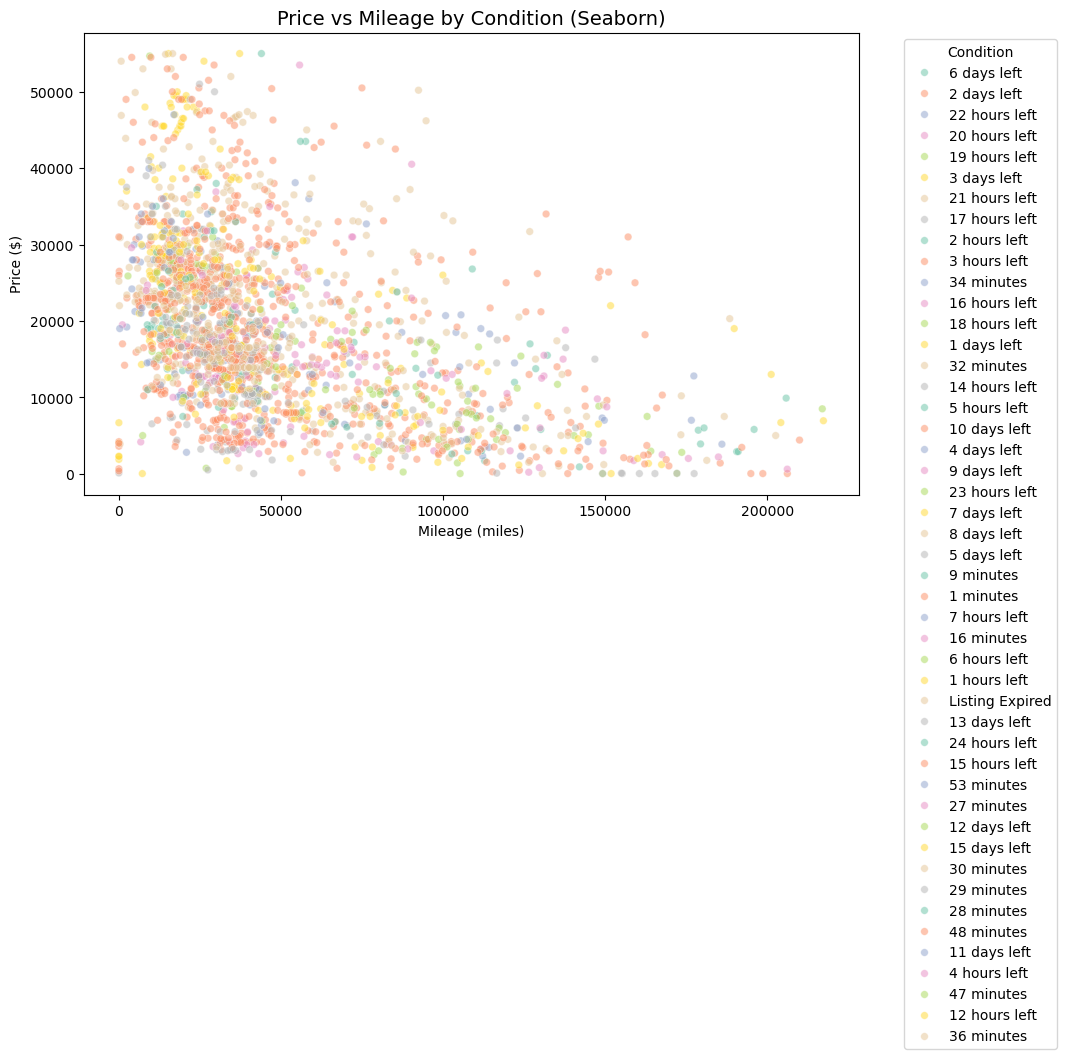

Insight: Higher mileage generally correlates with lower price. Cars with fewer days left tend to be priced lower.


In [4]:
# Remove mileage outliers for cleaner plot
df_scatter = df[df['mileage'] < df['mileage'].quantile(0.99)].copy()

# --- Plotly interactive scatter ---
fig = px.scatter(
    df_scatter,
    x='mileage', y='price',
    color='condition',
    hover_data=['brand', 'model', 'year', 'state'],
    title='Price vs Mileage — Color-Coded by Condition (Plotly)',
    labels={'mileage': 'Mileage (miles)', 'price': 'Price ($)', 'condition': 'Condition'},
    opacity=0.65,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(marker=dict(size=5))
fig.update_layout(legend_title_text='Condition')
fig.show()

# --- Also a Seaborn static version ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_scatter, x='mileage', y='price',
                hue='condition', alpha=0.5, s=30, palette='Set2')
plt.title('Price vs Mileage by Condition (Seaborn)', fontsize=14)
plt.xlabel('Mileage (miles)')
plt.ylabel('Price ($)')
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Insight: Higher mileage generally correlates with lower price. Cars with fewer days left tend to be priced lower.')

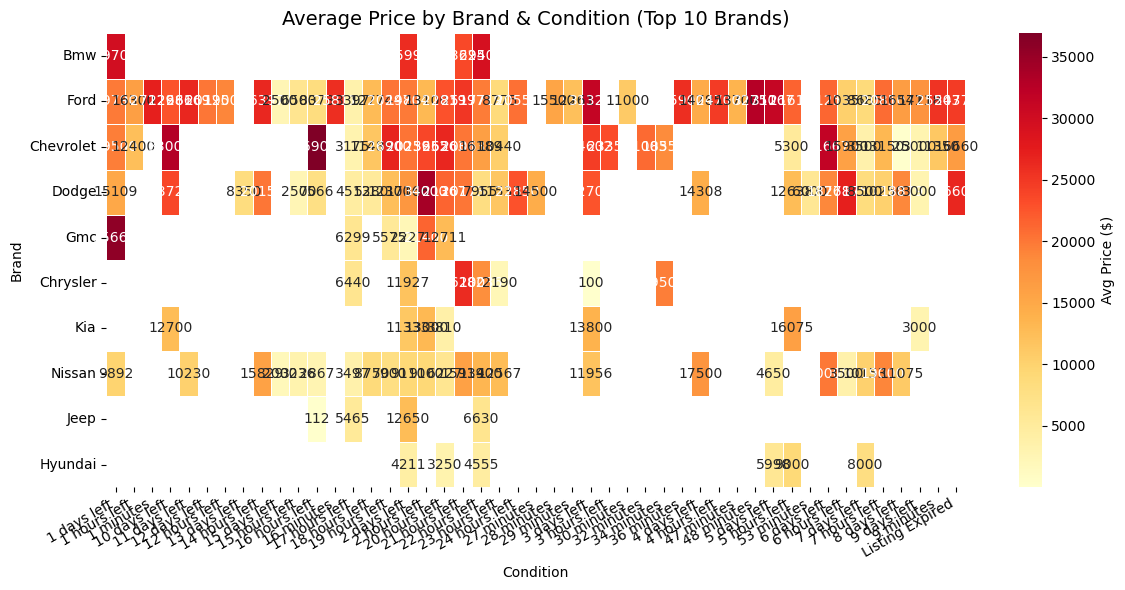

Insight: Dodge and Chevrolet command the highest average prices across most condition categories.


In [5]:
# Pivot table: avg price per brand (top 10) x condition
pivot = df_top10.pivot_table(values='price', index='brand', columns='condition', aggfunc='mean')

# Drop columns with all NaN
pivot = pivot.dropna(axis=1, how='all')

# Sort brands by overall average price
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

# --- Seaborn heatmap ---
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Avg Price ($)'})
plt.title('Average Price by Brand & Condition (Top 10 Brands)', fontsize=14)
plt.xlabel('Condition')
plt.ylabel('Brand')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# --- Plotly interactive heatmap ---
fig = px.imshow(
    pivot,
    text_auto='.0f',
    color_continuous_scale='YlOrRd',
    title='Average Price by Brand & Condition (Plotly — Interactive)',
    labels=dict(color='Avg Price ($)')
)
fig.show()

print('Insight: Dodge and Chevrolet command the highest average prices across most condition categories.')

## Conclusion

| Library | Best For |
|---------|----------|
| **Matplotlib** | Full control, publication-ready static plots |
| **Seaborn** | Statistical plots, cleaner defaults, easy grouping |
| **Plotly** | Interactive charts — hover, zoom, filter |

**Key Findings:**
- Car prices are right-skewed — most listings are under $15,000.
- Higher mileage strongly correlates with lower price.
- Dodge and Chevrolet show the highest average prices and widest price variance.
- The condition label (days left) acts as a proxy for auction urgency, not vehicle quality.